### Sreeharsha Varma Tinnannuri
### MSCS 634 - Adavanced Big Data and Data Mining
### Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis Using Python in Jupyter Notebook 

### Step 1: Data Collection

The dataset used in this lab is `SampleSuperstore.csv`. It contains retail transaction records from a superstore business. The data is loaded into a Pandas DataFrame for analysis.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [15]:
df = pd.read_csv("SampleSuperstore.csv", encoding="latin1")

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


### Step 2: Data Visualization

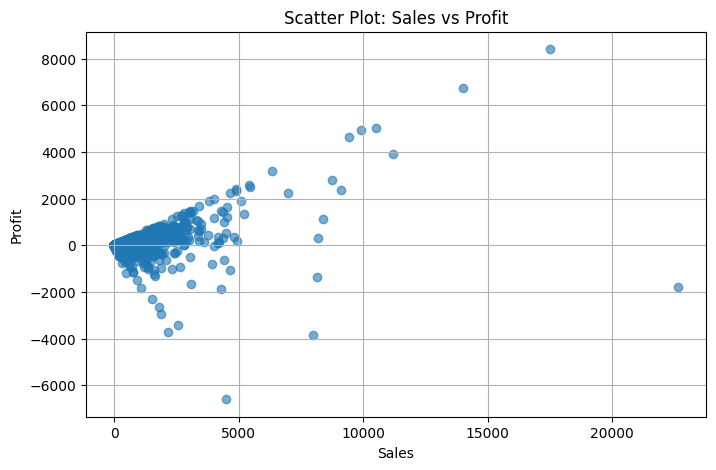

In [4]:
# Scatter Plot: Sales vs Profit
plt.figure(figsize=(8, 5))
plt.scatter(df["Sales"], df["Profit"], alpha=0.6)
plt.title("Scatter Plot: Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid(True)
plt.show()

**Scatter Plot Insight:**  
The scatter plot shows the relationship between sales and profit. Some transactions with high sales do not always generate high profit. This suggests that discounting, product category, and cost may affect profitability.

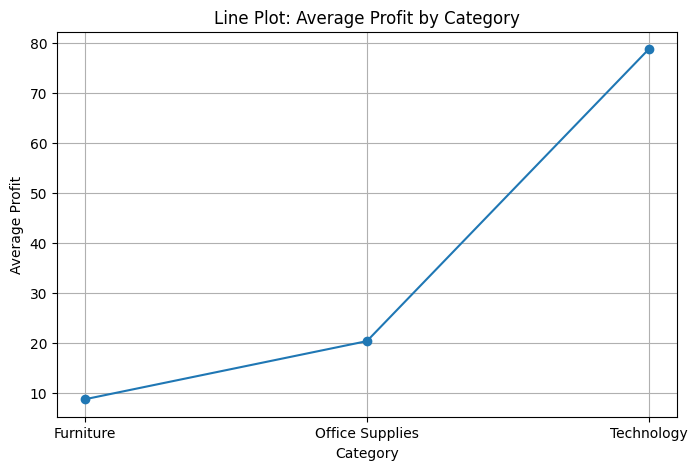

In [5]:
# Line Plot: Average Profit by Category
category_profit = df.groupby("Category")["Profit"].mean()

plt.figure(figsize=(8, 5))
plt.plot(category_profit.index, category_profit.values, marker="o")
plt.title("Line Plot: Average Profit by Category")
plt.xlabel("Category")
plt.ylabel("Average Profit")
plt.grid(True)
plt.show()

**Line Plot Insight:**  
The line plot compares average profit across product categories. It helps show which categories are more profitable on average.

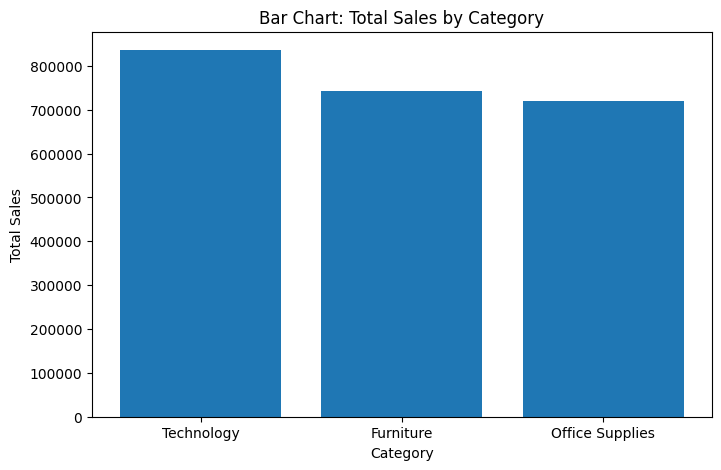

In [6]:
# Bar Chart: Total Sales by Category
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(category_sales.index, category_sales.values)
plt.title("Bar Chart: Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

**Bar Chart Insight:**  
The bar chart compares total sales across product categories. It helps identify which categories contribute the most to overall revenue.

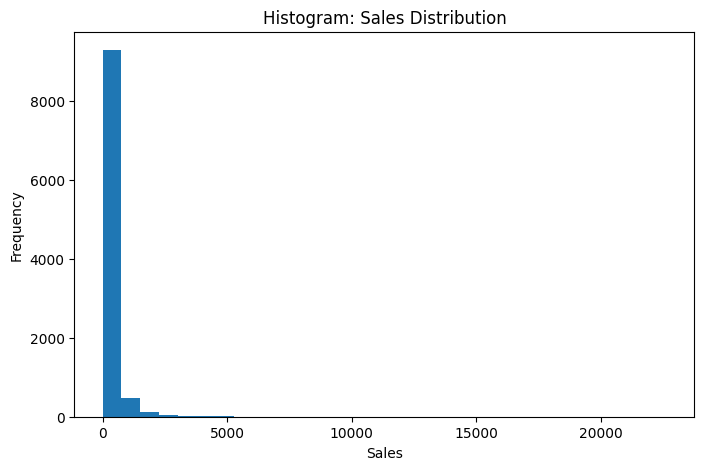

In [7]:
# Histogram: Sales Distribution
plt.figure(figsize=(8, 5))
plt.hist(df["Sales"], bins=30)
plt.title("Histogram: Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

**Histogram Insight:**  
The histogram shows that most sales transactions are relatively small, while a smaller number of transactions have very high sales values. This indicates a right-skewed distribution.

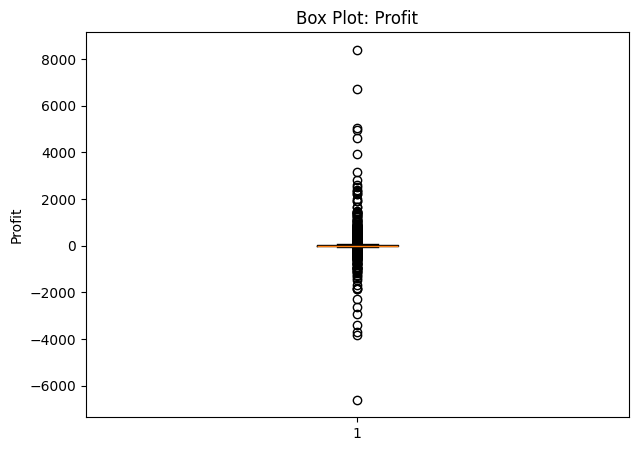

In [8]:
# Box Plot: Profit
plt.figure(figsize=(7, 5))
plt.boxplot(df["Profit"])
plt.title("Box Plot: Profit")
plt.ylabel("Profit")
plt.show()

**Box Plot Insight:**  
The box plot shows the spread of profit values and highlights potential outliers. Some transactions produce unusually high or low profit values.

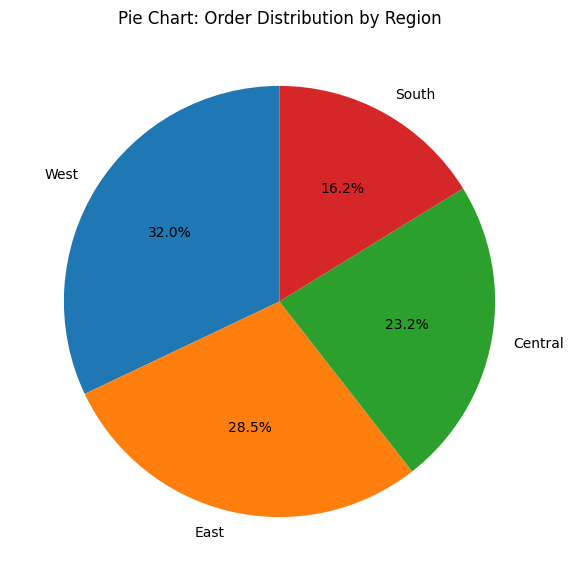

In [9]:
# Pie Chart: Order Distribution by Region
region_counts = df["Region"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(region_counts, labels=region_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Pie Chart: Order Distribution by Region")
plt.show()

**Pie Chart Insight:**  
The pie chart shows the proportion of records from each region. This helps compare how sales activity is distributed geographically.

### Step 3: Data Preprocessing

### 3.1 Handling Missing Values

In [16]:
# Detect missing values in each column
missing_values = df.isnull().sum()
missing_values

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [17]:
rows_with_missing = df[df.isnull().any(axis=1)]

if rows_with_missing.empty:
    print("No missing values were found in the dataset.")
else:
    display(rows_with_missing.head())

No missing values were found in the dataset.


In [20]:
df_clean = df.copy()

# Fill numerical missing values with the column mean
numeric_columns = df_clean.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

# Fill categorical missing values with the column mode
categorical_columns = df_clean.select_dtypes(include="object").columns

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean.isnull().sum()

/var/folders/t4/5gbrlxp1081c65lcstx33s240000gn/T/ipykernel_61059/1867020332.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_clean.select_dtypes(include="object").columns


Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [19]:
# Display first five rows after missing value handling
df_clean.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


The dataset was examined for missing values using the isnull() function. No missing values were detected in any column. Therefore, no imputation, row removal, or column removal was required. The dataset was already complete and suitable for further analysis.

### 3.2 Outlier Detection and Removal

The Interquartile Range method is used to detect outliers in the `Profit` column.

In [21]:
# IQR calculation for Profit
Q1 = df_clean["Profit"].quantile(0.25)
Q3 = df_clean["Profit"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 1.72875
Q3: 29.364
IQR: 27.63525
Lower Bound: -39.724125
Upper Bound: 70.816875


In [22]:
# Identify outliers in Profit
profit_outliers = df_clean[
    (df_clean["Profit"] < lower_bound) |
    (df_clean["Profit"] > upper_bound)
]

profit_outliers[["Sales", "Quantity", "Discount", "Profit", "Category", "Sub-Category", "Region"]].head(10)

,Sales,Quantity,Discount,Profit,Category,Sub-Category,Region
1,731.9400,3,0.00,219.5820,Furniture,Chairs,South
3,957.5775,5,0.45,-383.0310,Furniture,Tables,South
7,907.1520,6,0.20,90.7152,Technology,Phones,West
10,1706.1840,9,0.20,85.3092,Furniture,Tables,West
13,407.9760,3,0.20,132.5922,Office Supplies,Binders,West
14,68.8100,5,0.80,-123.8580,Office Supplies,Appliances,Central
24,1044.6300,3,0.00,240.2649,Furniture,Tables,West
27,3083.4300,7,0.50,-1665.0522,Furniture,Bookcases,East
35,1097.5440,7,0.20,123.4737,Technology,Phones,Central
36,190.9200,5,0.60,-147.9630,Furniture,Furnishings,Central


In [23]:
# Remove outliers from Profit
df_no_outliers = df_clean[
    (df_clean["Profit"] >= lower_bound) &
    (df_clean["Profit"] <= upper_bound)
]

print("Original dataset shape:", df_clean.shape)
print("Dataset shape after outlier removal:", df_no_outliers.shape)

df_no_outliers.head()

Original dataset shape: (9994, 13)
Dataset shape after outlier removal: (8113, 13)


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.960,2,0.0,41.9136
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.620,2,0.0,6.8714
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.368,2,0.2,2.5164
5,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,48.860,7,0.0,14.1694
6,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Art,7.280,4,0.0,1.9656


The IQR method was applied to the Profit column. Records below the lower bound or above the upper bound were identified as outliers. These records were removed to reduce the influence of extreme values on later analysis.

### 3.3 Data Reduction

In [24]:
# Dataset before reduction
df_no_outliers.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.960,2,0.0,41.9136
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.620,2,0.0,6.8714
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.368,2,0.2,2.5164
5,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Furnishings,48.860,7,0.0,14.1694
6,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Office Supplies,Art,7.280,4,0.0,1.9656


In [ ]:
# Apply sampling to reduce dataset size
df_sample = df_no_outliers.sample(frac=0.30, random_state=42)

# Drop less relevant columns
columns_to_drop = ["Postal Code", "Country"]
existing_columns_to_drop = [col for col in columns_to_drop if col in df_sample.columns]

df_reduced = df_sample.drop(columns=existing_columns_to_drop)

print("Shape before reduction:", df_no_outliers.shape)
print("Shape after reduction:", df_reduced.shape)

# Dataset after reduction
df_reduced.head()

Shape before reduction: (8113, 13)
Shape after reduction: (2434, 11)


,Ship Mode,Segment,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
2662,First Class,Home Office,Springfield,Missouri,Central,Office Supplies,Binders,8.76,2,0.0,4.2048
558,Standard Class,Consumer,Los Angeles,California,West,Office Supplies,Paper,32.40,5,0.0,15.5520
9913,First Class,Corporate,Santa Barbara,California,West,Office Supplies,Labels,31.05,3,0.0,14.9040
4902,Standard Class,Consumer,New York City,New York,East,Office Supplies,Binders,25.92,6,0.2,9.0720
6605,Standard Class,Consumer,Santa Ana,California,West,Office Supplies,Paper,45.36,7,0.0,21.7728


A 30% sample was selected from the cleaned dataset. The `Postal Code` and `Country` columns were removed because they are less relevant for this analysis. The country column contains the same value for all records, and postal code is more useful as an identifier than as an analytical variable.

### 3.4 Data Scaling and Discretization

In [26]:
# Data before scaling
df_reduced[["Sales", "Profit", "Quantity", "Discount"]].head()

,Sales,Profit,Quantity,Discount
2662,8.76,4.2048,2,0.0
558,32.40,15.5520,5,0.0
9913,31.05,14.9040,3,0.0
4902,25.92,9.0720,6,0.2
6605,45.36,21.7728,7,0.0


In [27]:
# Min-Max scaling
df_scaled = df_reduced.copy()

scale_columns = ["Sales", "Profit", "Quantity", "Discount"]

for col in scale_columns:
    df_scaled[col + "_MinMax"] = (
        (df_scaled[col] - df_scaled[col].min()) /
        (df_scaled[col].max() - df_scaled[col].min())
    )

# Discretize Sales into categories
df_scaled["Sales_Category"] = pd.cut(
    df_scaled["Sales"],
    bins=[0, 100, 500, 1000, float("inf")],
    labels=["Low", "Medium", "High", "Very High"]
)

df_scaled[
    [
        "Sales", "Sales_MinMax",
        "Profit", "Profit_MinMax",
        "Quantity", "Quantity_MinMax",
        "Discount", "Discount_MinMax",
        "Sales_Category"
    ]
].head()

,Sales,Sales_MinMax,Profit,Profit_MinMax,Quantity,Quantity_MinMax,Discount,Discount_MinMax,Sales_Category
2662,8.76,0.002966,4.2048,0.397177,2,0.076923,0.0,0.00,Low
558,32.40,0.011399,15.5520,0.500270,5,0.307692,0.0,0.00,Low
9913,31.05,0.010917,14.9040,0.494383,3,0.153846,0.0,0.00,Low
4902,25.92,0.009087,9.0720,0.441397,6,0.384615,0.2,0.25,Low
6605,45.36,0.016022,21.7728,0.556788,7,0.461538,0.0,0.00,Low


Min-Max Scaling converted selected numerical variables into values between 0 and 1. Sales values were also grouped into Low, Medium, High, and Very High categories to make interpretation easier.

### Step 4: Statistical Analysis

### 4.1 General Overview of Data

In [28]:
df_scaled.info()

<class 'pandas.DataFrame'>
Index: 2434 entries, 2662 to 972
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Ship Mode        2434 non-null   str     
 1   Segment          2434 non-null   str     
 2   City             2434 non-null   str     
 3   State            2434 non-null   str     
 4   Region           2434 non-null   str     
 5   Category         2434 non-null   str     
 6   Sub-Category     2434 non-null   str     
 7   Sales            2434 non-null   float64 
 8   Quantity         2434 non-null   int64   
 9   Discount         2434 non-null   float64 
 10  Profit           2434 non-null   float64 
 11  Sales_MinMax     2434 non-null   float64 
 12  Profit_MinMax    2434 non-null   float64 
 13  Quantity_MinMax  2434 non-null   float64 
 14  Discount_MinMax  2434 non-null   float64 
 15  Sales_Category   2434 non-null   category
dtypes: category(1), float64(7), int64(1), str(7)
memory usag

In [30]:
df_scaled.describe()

,Sales,Quantity,Discount,Profit,Sales_MinMax,Profit_MinMax,Quantity_MinMax,Discount_MinMax
count,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000,2434.000000
mean,90.454074,3.555053,0.150781,11.594906,0.032107,0.464319,0.196543,0.188476
std,158.673521,2.091724,0.201948,18.795421,0.056599,0.170762,0.160902,0.252436
min,0.444000,1.000000,0.000000,-39.511800,0.000000,0.000000,0.000000,0.000000
25%,14.620000,2.000000,0.000000,1.814400,0.005057,0.375460,0.076923,0.000000
50%,35.264000,3.000000,0.200000,7.514000,0.012420,0.427242,0.153846,0.250000
75%,95.986000,5.000000,0.200000,18.984150,0.034080,0.531452,0.307692,0.250000
max,2803.920000,14.000000,0.800000,70.556400,1.000000,1.000000,1.000000,1.000000


### 4.2 Central Tendency Measures

In [31]:
# Minimum, maximum, mean, median, and mode
numeric_cols = ["Sales", "Profit", "Quantity", "Discount"]

central_tendency = pd.DataFrame({
    "Minimum": df_scaled[numeric_cols].min(),
    "Maximum": df_scaled[numeric_cols].max(),
    "Mean": df_scaled[numeric_cols].mean(),
    "Median": df_scaled[numeric_cols].median(),
    "Mode": df_scaled[numeric_cols].mode().iloc[0]
})

central_tendency

,Minimum,Maximum,Mean,Median,Mode
Sales,0.4440,2803.9200,90.454074,35.264,12.96
Profit,-39.5118,70.5564,11.594906,7.514,0.00
Quantity,1.0000,14.0000,3.555053,3.000,2.00
Discount,0.0000,0.8000,0.150781,0.200,0.00


The minimum and maximum show the range of values. The mean and median summarize typical values, while the mode shows the most frequently occurring value.

### 4.3 Dispersion Measures

In [32]:
# Range, quartiles, IQR, variance, and standard deviation
dispersion = pd.DataFrame(index=numeric_cols)

dispersion["Range"] = df_scaled[numeric_cols].max() - df_scaled[numeric_cols].min()
dispersion["Q1"] = df_scaled[numeric_cols].quantile(0.25)
dispersion["Q3"] = df_scaled[numeric_cols].quantile(0.75)
dispersion["IQR"] = dispersion["Q3"] - dispersion["Q1"]
dispersion["Variance"] = df_scaled[numeric_cols].var()
dispersion["Standard Deviation"] = df_scaled[numeric_cols].std()

dispersion

,Range,Q1,Q3,IQR,Variance,Standard Deviation
Sales,2803.4760,14.6200,95.98600,81.36600,25177.286225,158.673521
Profit,110.0682,1.8144,18.98415,17.16975,353.267859,18.795421
Quantity,13.0000,2.0000,5.00000,3.00000,4.375307,2.091724
Discount,0.8000,0.0000,0.20000,0.20000,0.040783,0.201948


Dispersion measures show how spread out the data values are. The IQR is especially useful because it is less affected by extreme values than range.

### 4.4 Correlation Analysis

In [33]:
# Correlation matrix for numerical columns
correlation_matrix = df_scaled[numeric_cols].corr()
correlation_matrix

,Sales,Profit,Quantity,Discount
Sales,1.000000,0.320561,0.153081,-0.044856
Profit,0.320561,1.000000,0.165387,-0.446601
Quantity,0.153081,0.165387,1.000000,0.013043
Discount,-0.044856,-0.446601,0.013043,1.000000


The correlation matrix shows relationships between numerical variables. Positive values indicate that two variables tend to increase together, while negative values indicate that one variable may decrease as the other increases.